In [1]:
!pip install polars scikit-learn scipy category_encoders -q


[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: python3.11 -m pip install --upgrade pip


In [2]:
import numpy as np 
import polars as pl 
from scipy.stats import pointbiserialr

from sklearn.linear_model import LogisticRegression 
from sklearn.svm import SVC 

from sklearn.preprocessing import StandardScaler 
from category_encoders import TargetEncoder

from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import plotly.express as px
import warnings 

warnings.filterwarnings('ignore')

In [3]:
df = pl.read_csv('data/кибератаки.csv', try_parse_dates=True)

df

Timestamp,Source_IP,Destination_IP,Protocol,Packet_Length,Duration,Source_Port,Destination_Port,Bytes_Sent,Bytes_Received,Flags,Flow_Packets/s,Flow_Bytes/s,Avg_Packet_Size,Total_Fwd_Packets,Total_Bwd_Packets,Fwd_Header_Length,Bwd_Header_Length,Sub_Flow_Fwd_Bytes,Sub_Flow_Bwd_Bytes,Inbound,Attack_Type,Label
datetime[μs],str,str,str,i64,f64,i64,i64,i64,i64,str,f64,f64,i64,i64,i64,i64,i64,i64,i64,i64,str,i64
2024-10-23 12:00:00,"""192.168.0.1""","""192.168.0.1""","""ICMP""",1155,4.01,53,53,675,877,"""SYN""",37.9,583.2,512,21,34,256,256,697,1028,1,"""DDoS""",1
2024-10-23 12:00:01,"""192.168.0.7""","""172.16.0.5""","""ICMP""",1776,3.75,22,22,297,1062,"""ACK""",37.8,1100.6,1024,14,19,512,256,513,1300,1,"""DDoS""",1
2024-10-23 12:00:02,"""192.168.0.7""","""10.0.0.3""","""UDP""",627,4.24,80,8080,122,723,"""ACK""",12.3,339.1,512,10,41,512,256,250,497,0,"""DDoS""",1
2024-10-23 12:00:03,"""192.168.0.7""","""10.0.0.3""","""UDP""",1754,3.09,443,443,1626,1703,"""FIN""",19.2,1913.5,256,37,44,128,256,985,1471,0,"""Ransomware""",0
2024-10-23 12:00:04,"""192.168.0.1""","""10.0.0.4""","""UDP""",1326,2.52,80,443,1851,771,"""PSH""",16.2,105.9,1024,40,16,512,256,1877,595,1,"""Normal""",1
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2024-10-23 12:23:45,"""10.0.0.9""","""10.0.0.3""","""UDP""",1260,0.46,22,8080,722,626,"""PSH""",38.9,509.6,256,37,17,512,512,1021,1996,1,"""Ransomware""",1
2024-10-23 12:23:46,"""10.0.0.9""","""172.16.0.5""","""TCP""",362,2.02,8080,22,571,1006,"""ACK""",16.6,596.8,1024,27,24,128,128,381,260,1,"""Normal""",1
2024-10-23 12:23:47,"""172.16.0.4""","""10.0.0.3""","""TCP""",1236,2.11,8080,80,1194,185,"""ACK""",37.2,750.1,512,15,46,256,256,1064,170,1,"""Normal""",1


In [4]:
df.describe()

statistic,Timestamp,Source_IP,Destination_IP,Protocol,Packet_Length,Duration,Source_Port,Destination_Port,Bytes_Sent,Bytes_Received,Flags,Flow_Packets/s,Flow_Bytes/s,Avg_Packet_Size,Total_Fwd_Packets,Total_Bwd_Packets,Fwd_Header_Length,Bwd_Header_Length,Sub_Flow_Fwd_Bytes,Sub_Flow_Bwd_Bytes,Inbound,Attack_Type,Label
str,str,str,str,str,f64,f64,f64,f64,f64,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,f64
"""count""","""1430""","""1430""","""1430""","""1430""",1430.0,1429.0,1430.0,1430.0,1430.0,1430.0,"""1430""",1429.0,1430.0,1430.0,1430.0,1429.0,1430.0,1430.0,1430.0,1430.0,1430.0,"""1430""",1430.0
"""null_count""","""0""","""0""","""0""","""0""",0.0,1.0,0.0,0.0,0.0,0.0,"""0""",1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,"""0""",0.0
"""mean""","""2024-10-23 12:11:54.500000""",null,null,null,1064.52028,2.585724,1673.184615,1848.512587,1015.9,1045.531469,null,24.785584,1070.64014,460.128671,29.279021,29.677397,306.483916,295.742657,1074.735664,1064.494406,0.524476,null,0.488112
"""std""",null,null,null,null,572.437816,1.42068,3124.172914,3275.839849,569.400101,572.170268,null,8.771325,562.422385,360.760328,11.530216,11.219739,159.092478,160.405437,565.793704,542.027082,0.499575,null,0.500034
"""min""","""2024-10-23 12:00:00""","""10.0.0.5""","""10.0.0.3""","""ICMP""",64.0,0.1,22.0,22.0,65.0,64.0,"""ACK""",10.0,100.2,64.0,10.0,10.0,128.0,128.0,130.0,128.0,0.0,"""Brute Force""",0.0
"""25%""","""2024-10-23 12:05:57""",null,null,null,562.0,1.36,53.0,53.0,503.0,521.0,null,17.2,585.3,256.0,19.0,20.0,128.0,128.0,583.0,601.0,0.0,null,0.0
"""50%""","""2024-10-23 12:11:55""",null,null,null,1067.0,2.6,80.0,80.0,1019.0,1045.0,null,24.9,1072.1,256.0,29.0,30.0,256.0,256.0,1083.0,1042.0,1.0,null,0.0
"""75%""","""2024-10-23 12:17:52""",null,null,null,1539.0,3.84,443.0,443.0,1497.0,1540.0,null,32.1,1559.9,1024.0,39.0,39.0,512.0,512.0,1564.0,1527.0,1.0,null,1.0
"""max""","""2024-10-23 12:23:49""","""192.168.0.8""","""192.168.0.2""","""UDP""",2046.0,5.0,8080.0,8080.0,2045.0,2044.0,"""SYN""",40.0,2047.9,1024.0,49.0,49.0,512.0,512.0,2047.0,2045.0,1.0,"""Ransomware""",1.0


In [5]:
df = df.drop_nulls() # удаляем всего лишь 3 строки, что не критично

df

Timestamp,Source_IP,Destination_IP,Protocol,Packet_Length,Duration,Source_Port,Destination_Port,Bytes_Sent,Bytes_Received,Flags,Flow_Packets/s,Flow_Bytes/s,Avg_Packet_Size,Total_Fwd_Packets,Total_Bwd_Packets,Fwd_Header_Length,Bwd_Header_Length,Sub_Flow_Fwd_Bytes,Sub_Flow_Bwd_Bytes,Inbound,Attack_Type,Label
datetime[μs],str,str,str,i64,f64,i64,i64,i64,i64,str,f64,f64,i64,i64,i64,i64,i64,i64,i64,i64,str,i64
2024-10-23 12:00:00,"""192.168.0.1""","""192.168.0.1""","""ICMP""",1155,4.01,53,53,675,877,"""SYN""",37.9,583.2,512,21,34,256,256,697,1028,1,"""DDoS""",1
2024-10-23 12:00:01,"""192.168.0.7""","""172.16.0.5""","""ICMP""",1776,3.75,22,22,297,1062,"""ACK""",37.8,1100.6,1024,14,19,512,256,513,1300,1,"""DDoS""",1
2024-10-23 12:00:02,"""192.168.0.7""","""10.0.0.3""","""UDP""",627,4.24,80,8080,122,723,"""ACK""",12.3,339.1,512,10,41,512,256,250,497,0,"""DDoS""",1
2024-10-23 12:00:03,"""192.168.0.7""","""10.0.0.3""","""UDP""",1754,3.09,443,443,1626,1703,"""FIN""",19.2,1913.5,256,37,44,128,256,985,1471,0,"""Ransomware""",0
2024-10-23 12:00:04,"""192.168.0.1""","""10.0.0.4""","""UDP""",1326,2.52,80,443,1851,771,"""PSH""",16.2,105.9,1024,40,16,512,256,1877,595,1,"""Normal""",1
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
2024-10-23 12:23:45,"""10.0.0.9""","""10.0.0.3""","""UDP""",1260,0.46,22,8080,722,626,"""PSH""",38.9,509.6,256,37,17,512,512,1021,1996,1,"""Ransomware""",1
2024-10-23 12:23:46,"""10.0.0.9""","""172.16.0.5""","""TCP""",362,2.02,8080,22,571,1006,"""ACK""",16.6,596.8,1024,27,24,128,128,381,260,1,"""Normal""",1
2024-10-23 12:23:47,"""172.16.0.4""","""10.0.0.3""","""TCP""",1236,2.11,8080,80,1194,185,"""ACK""",37.2,750.1,512,15,46,256,256,1064,170,1,"""Normal""",1


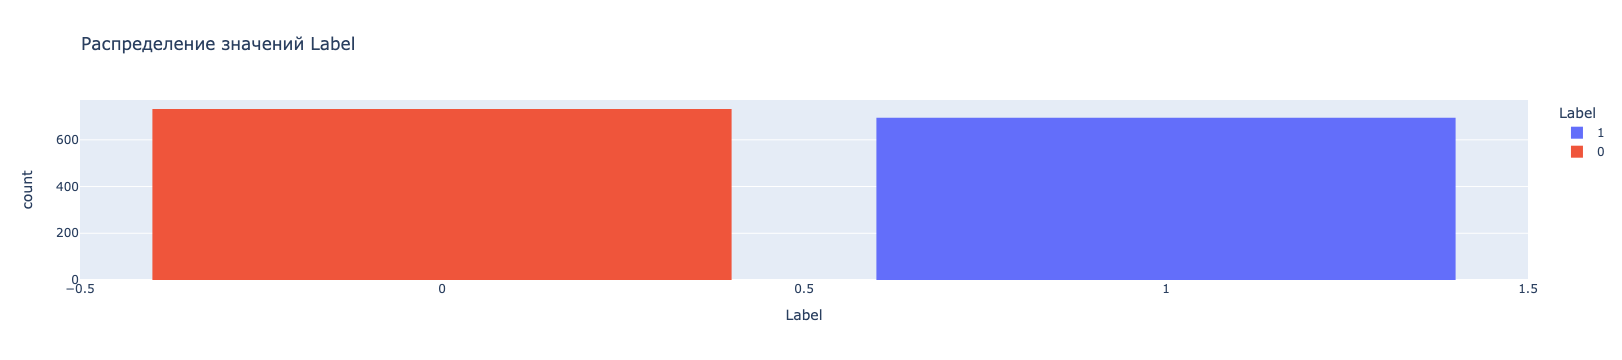

In [6]:
fig = px.histogram(
    df,
    x="Label",
    title="Распределение значений Label",
    labels={"Label": "Label", "count": "Количество"},
    color="Label",
)
fig.update_layout(bargap=0.2)
fig.show()

In [7]:
numeric_cols = df.select(pl.col(pl.NUMERIC_DTYPES)).columns
correlation_matrix = df.select(numeric_cols).corr()

print(correlation_matrix)

shape: (17, 17)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ Packet_Le ┆ Duration  ┆ Source_Po ┆ Destinati ┆ … ┆ Sub_Flow_ ┆ Sub_Flow_ ┆ Inbound   ┆ Label    │
│ ngth      ┆ ---       ┆ rt        ┆ on_Port   ┆   ┆ Fwd_Bytes ┆ Bwd_Bytes ┆ ---       ┆ ---      │
│ ---       ┆ f64       ┆ ---       ┆ ---       ┆   ┆ ---       ┆ ---       ┆ f64       ┆ f64      │
│ f64       ┆           ┆ f64       ┆ f64       ┆   ┆ f64       ┆ f64       ┆           ┆          │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ 1.0       ┆ -0.006699 ┆ 0.042565  ┆ -0.03302  ┆ … ┆ -0.050409 ┆ 0.031131  ┆ 0.044502  ┆ -0.02183 │
│           ┆           ┆           ┆           ┆   ┆           ┆           ┆           ┆ 1        │
│ -0.006699 ┆ 1.0       ┆ -0.001533 ┆ 0.005964  ┆ … ┆ -0.011635 ┆ 0.010935  ┆ 0.078485  ┆ 0.011345 │
│ 0.042565  ┆ -0.001533 ┆ 1.0       ┆ -0.026245 ┆ … ┆ -0.008852 ┆ -0.013124

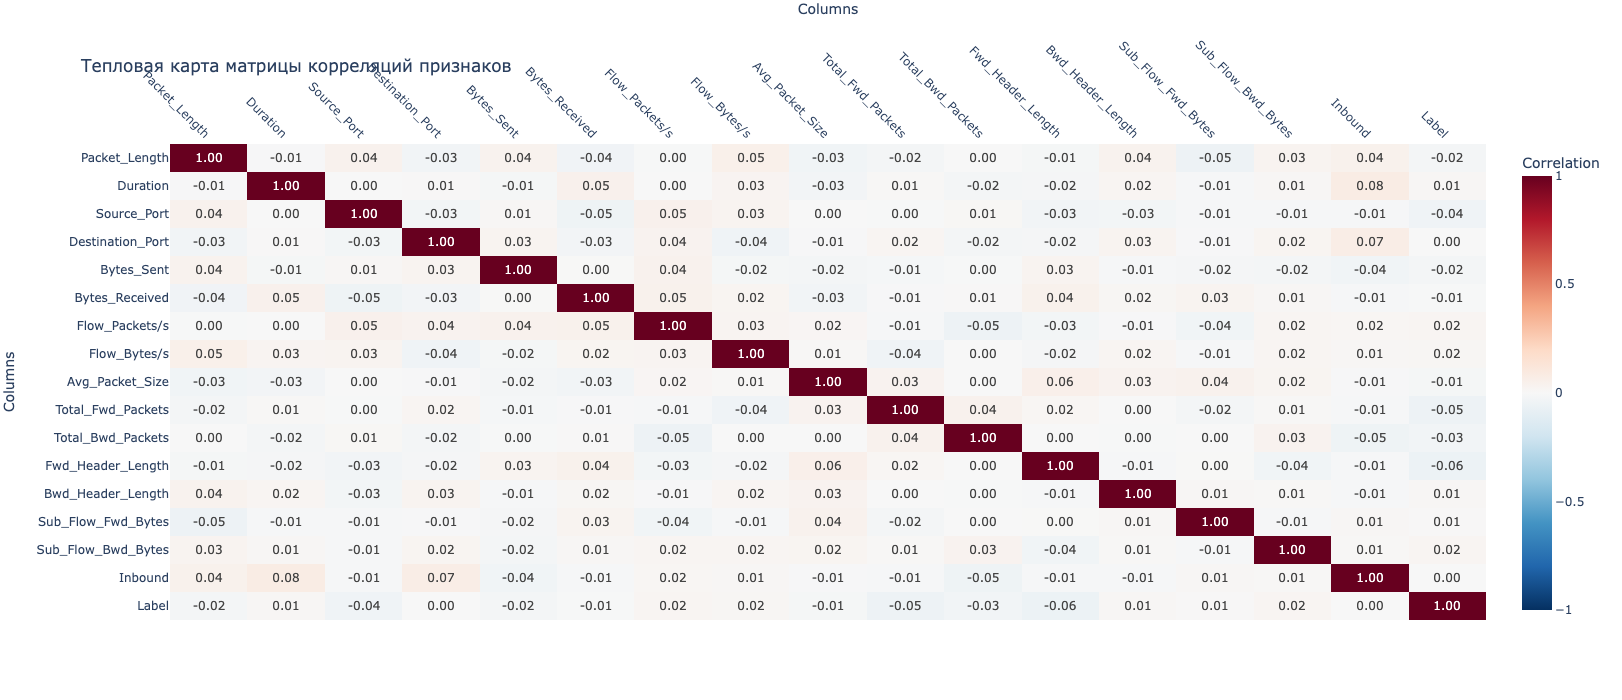

In [8]:
cols = correlation_matrix.columns

fig = px.imshow(
    correlation_matrix,
    text_auto=".2f",
    aspect="auto",
    color_continuous_scale="RdBu_r",
    range_color=[-1, 1],
    labels=dict(color="Correlation", x="Columns", y="Columns"),
    x=cols,
    y=cols,
    title="Тепловая карта матрицы корреляций признаков"
)

fig.update_xaxes(side="top")
fig.update_layout(height=700, width=800)
fig.update_xaxes(tickangle=45)

fig.show()

In [9]:
target_col = "Label"

numeric_cols = [c for c in df.select(pl.col(pl.NUMERIC_DTYPES)).columns if c != target_col]
df_num = df.select([target_col] + numeric_cols)

corrs = {}
for col in numeric_cols:
    corr, pval = pointbiserialr(df_num[target_col], df_num[col])
    corrs[col] = corr

corr_series = pl.DataFrame({
    "feature": list(corrs.keys()),
    "point_biserial_corr": list(corrs.values())
}).sort("point_biserial_corr", descending=True)

corr_series

feature,point_biserial_corr
str,f64
"""Sub_Flow_Bwd_Bytes""",0.020941
"""Flow_Packets/s""",0.020332
"""Flow_Bytes/s""",0.016045
"""Bwd_Header_Length""",0.011486
"""Duration""",0.011345
…,…
"""Bytes_Sent""",-0.023047
"""Total_Bwd_Packets""",-0.033787
"""Source_Port""",-0.041592


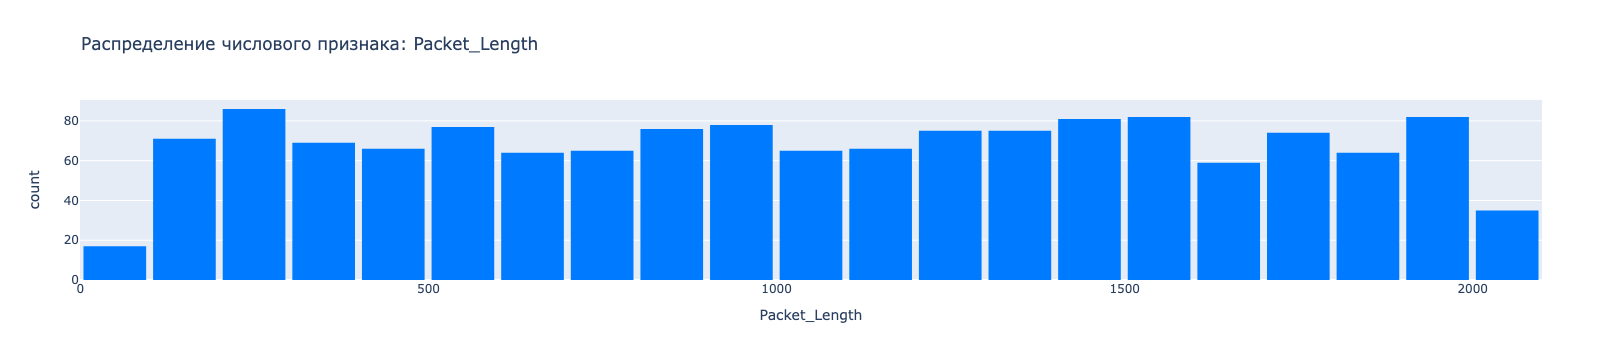

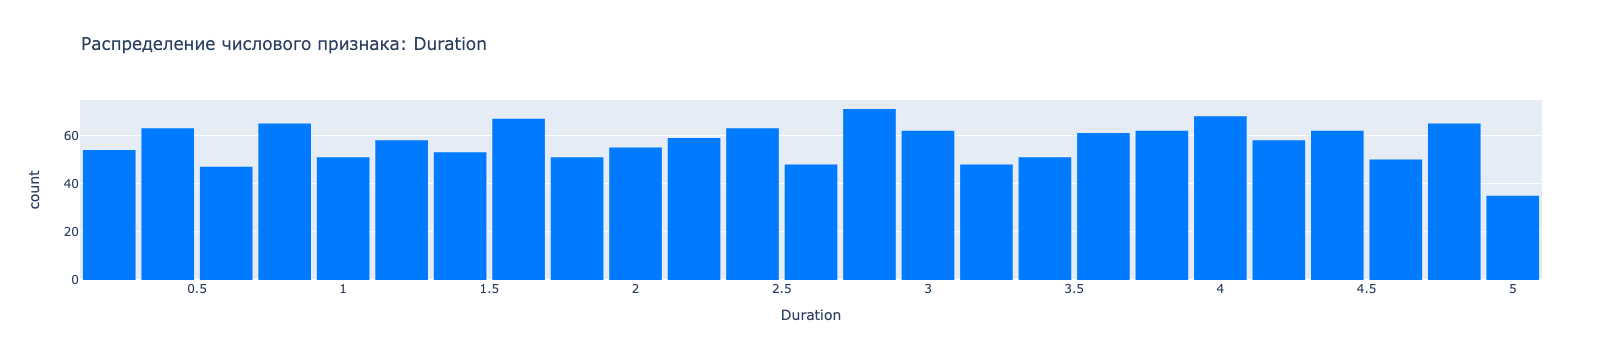

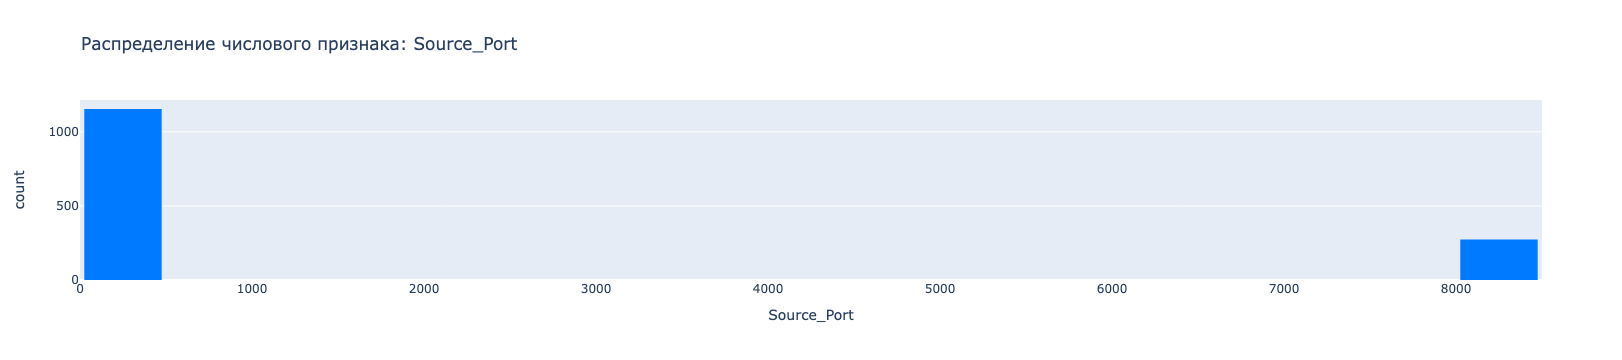

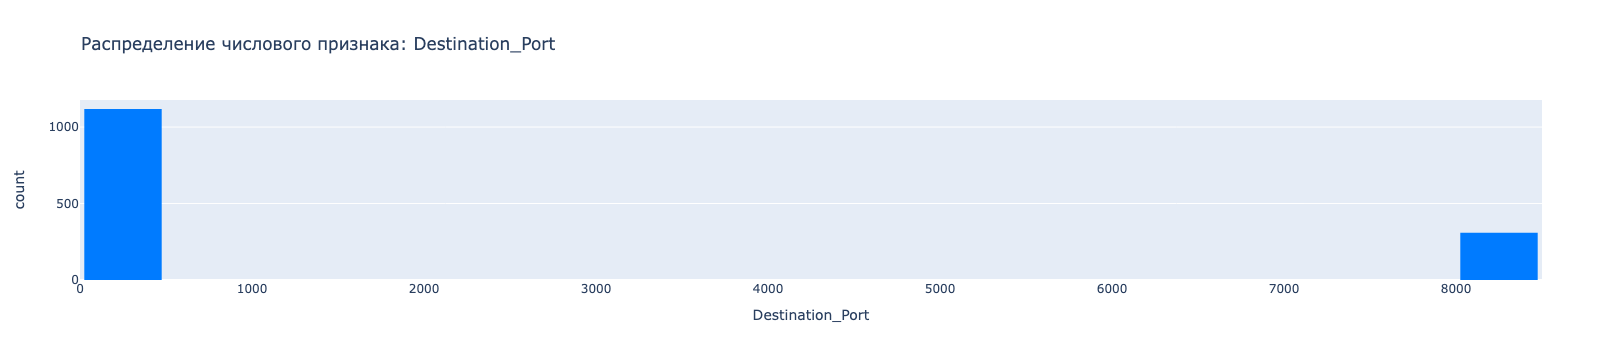

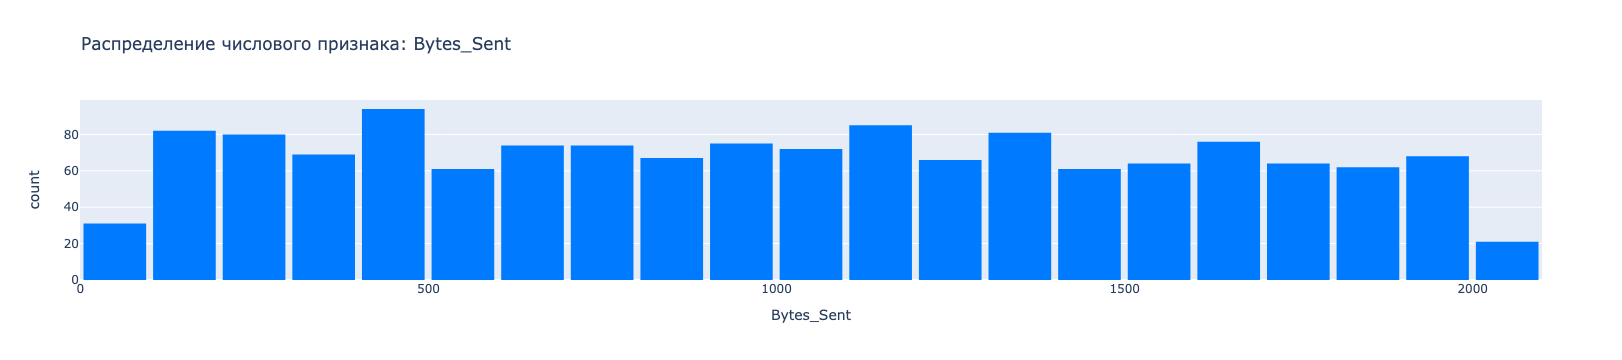

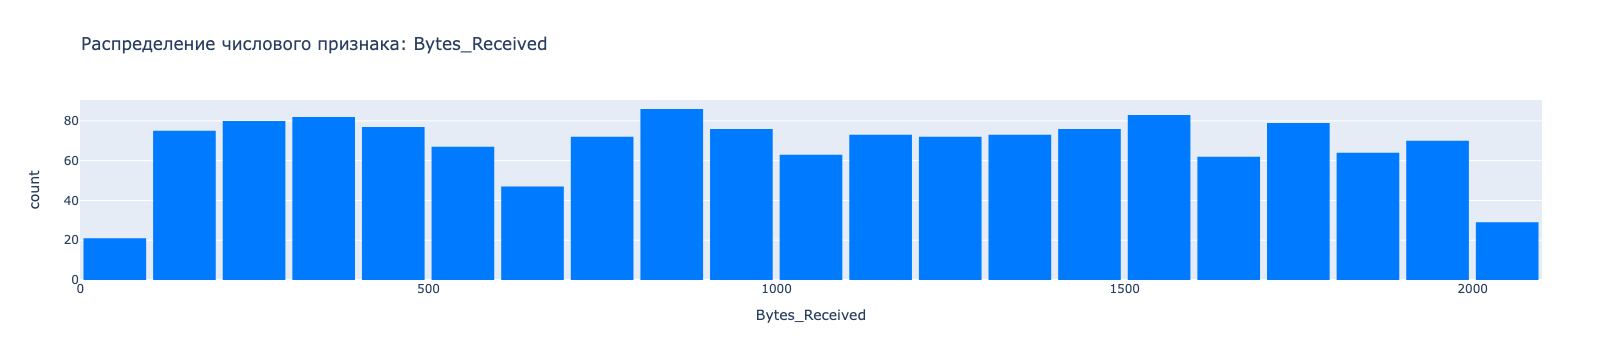

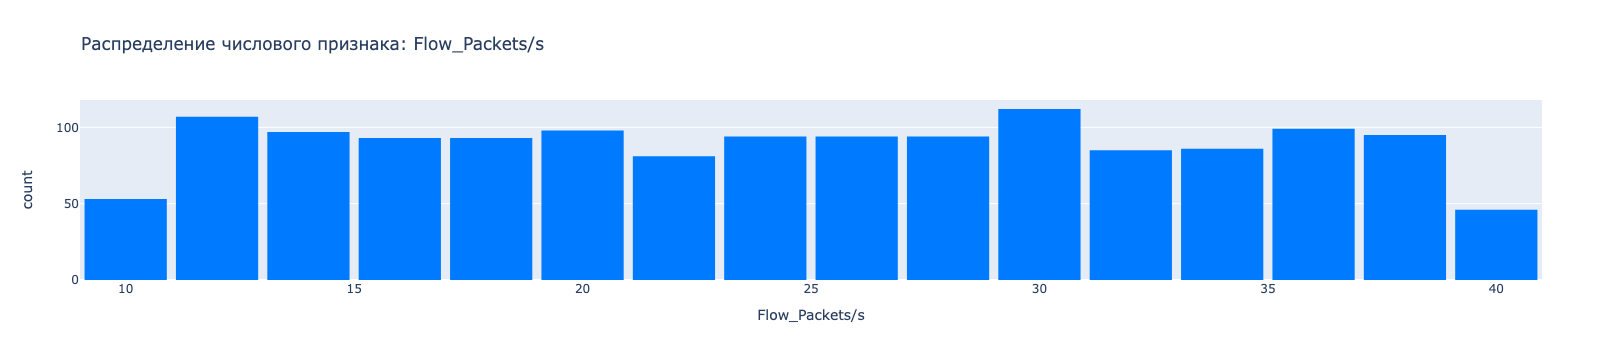

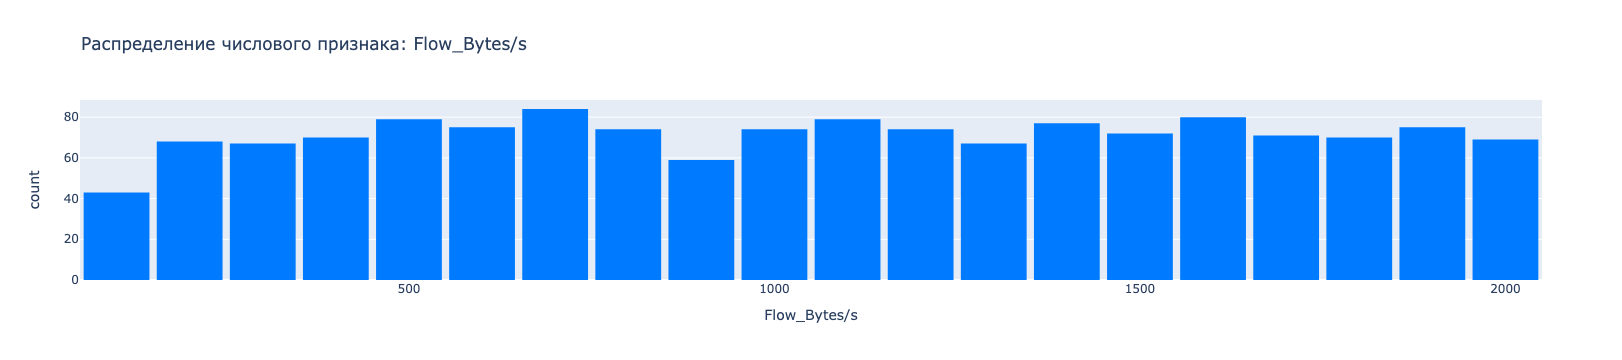

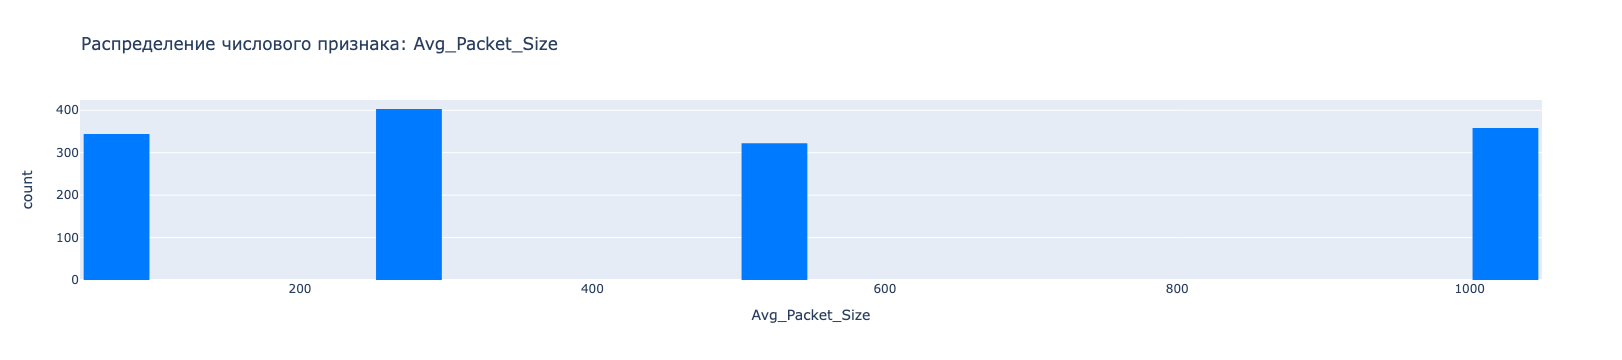

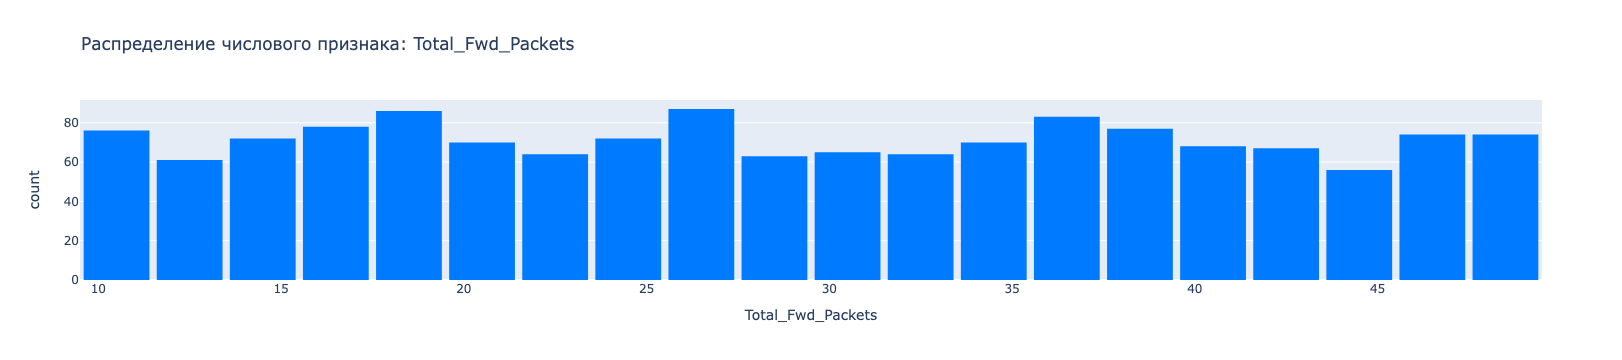

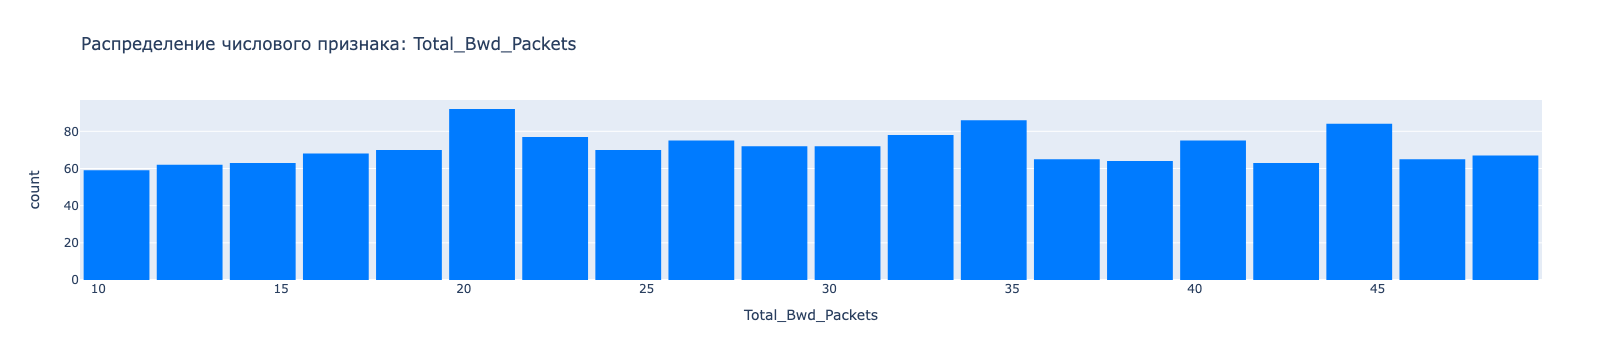

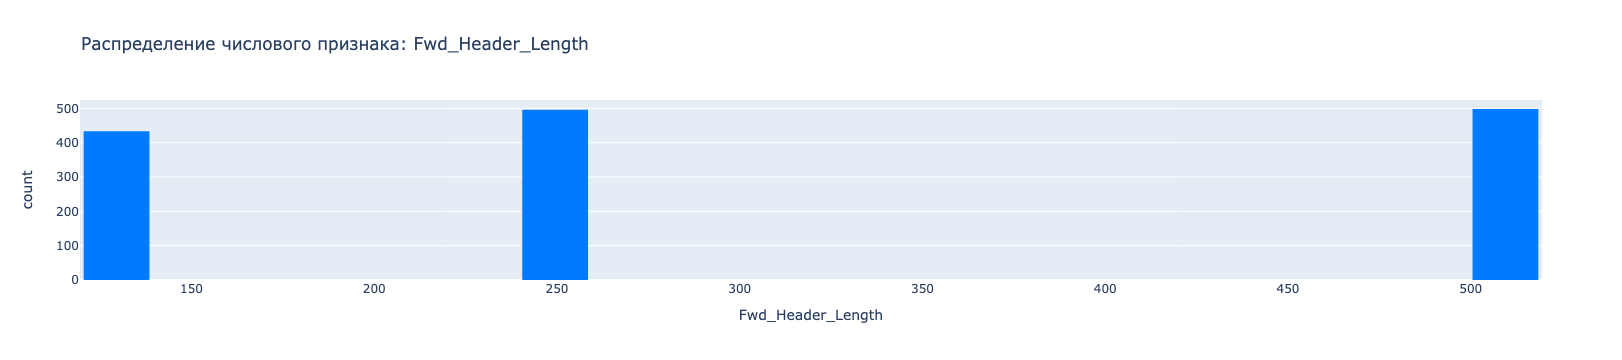

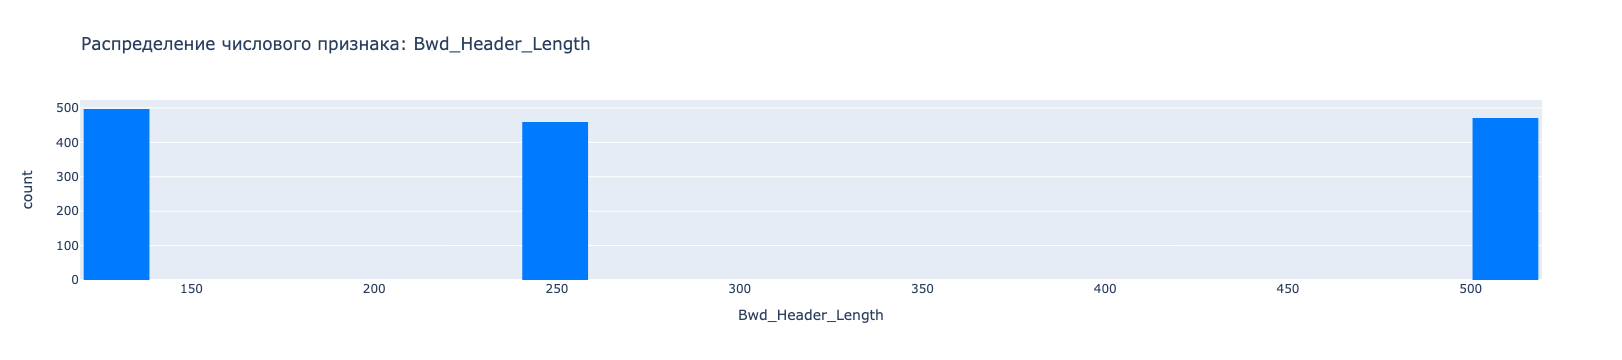

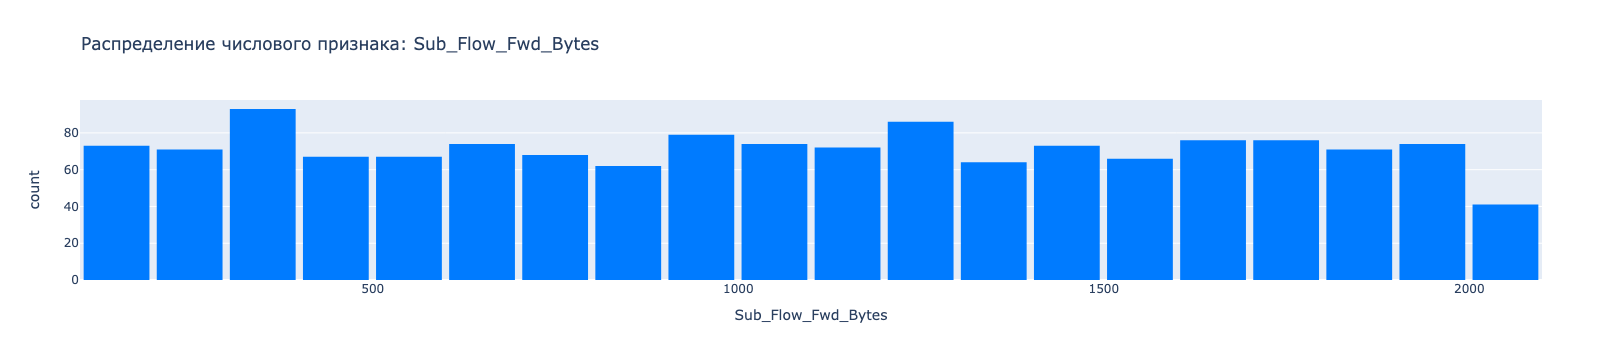

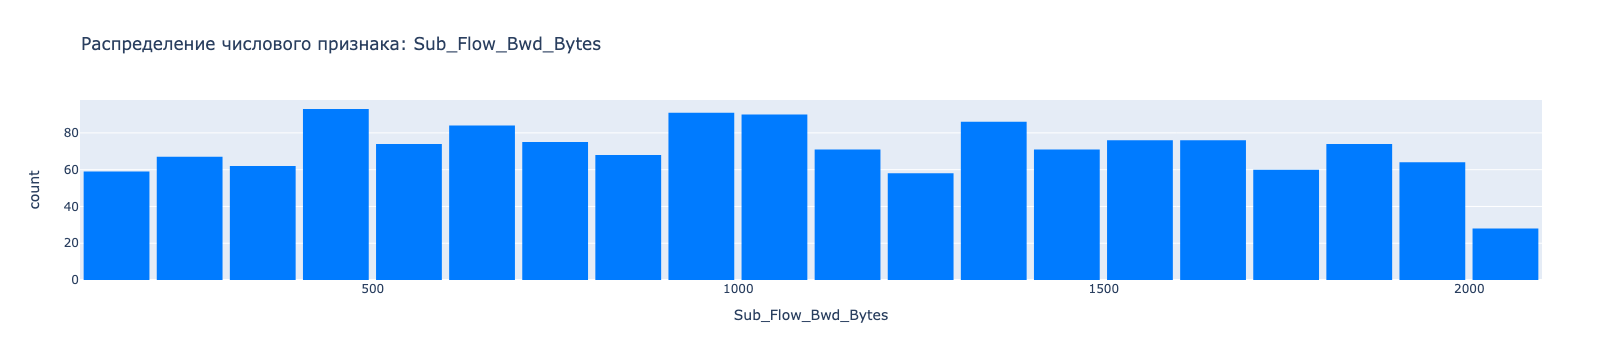

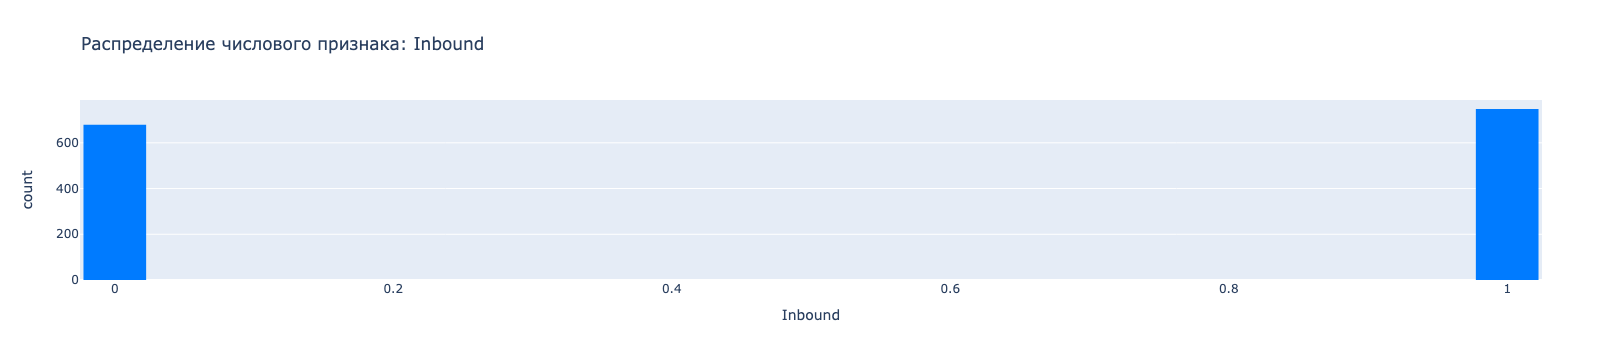

In [10]:
cat_cols = [c for c in df.columns if c not in numeric_cols]

for col in numeric_cols:
    fig = px.histogram(
        df,
        x=col,
        nbins=30,
        title=f"Распределение числового признака: {col}",
        labels={col: col, "count": "Количество"},
        color_discrete_sequence=["#007bff"]
    )
    fig.update_layout(bargap=0.1)
    fig.show()

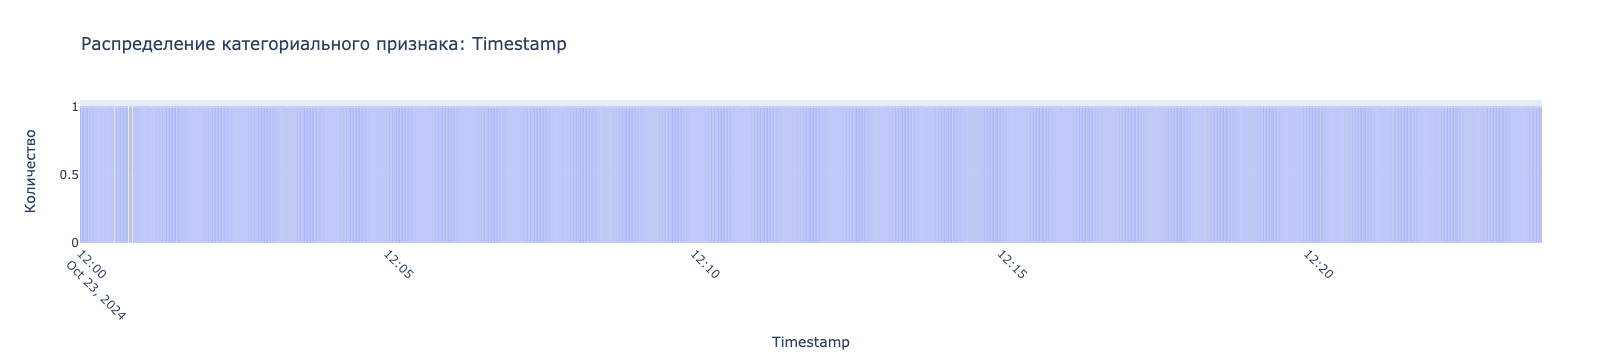

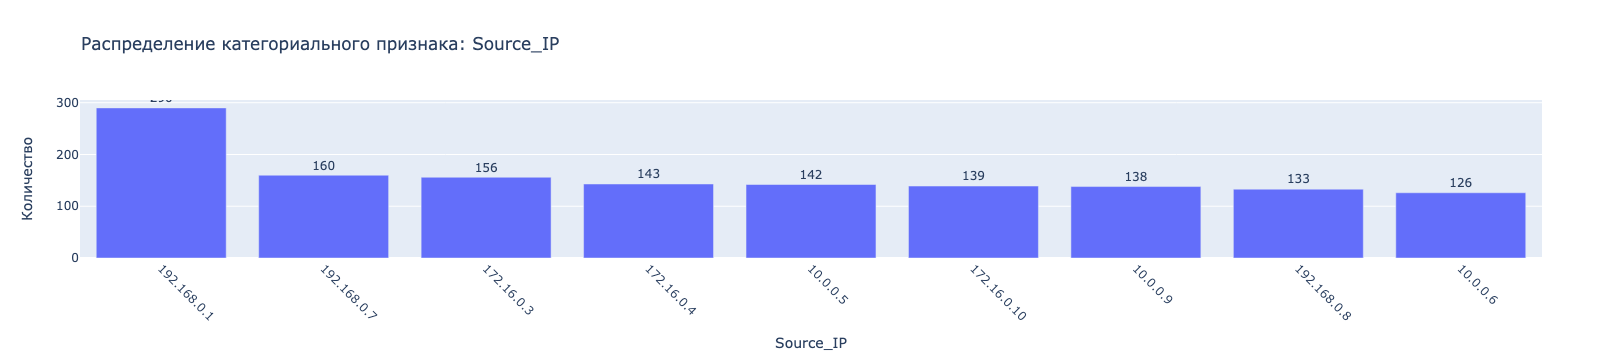

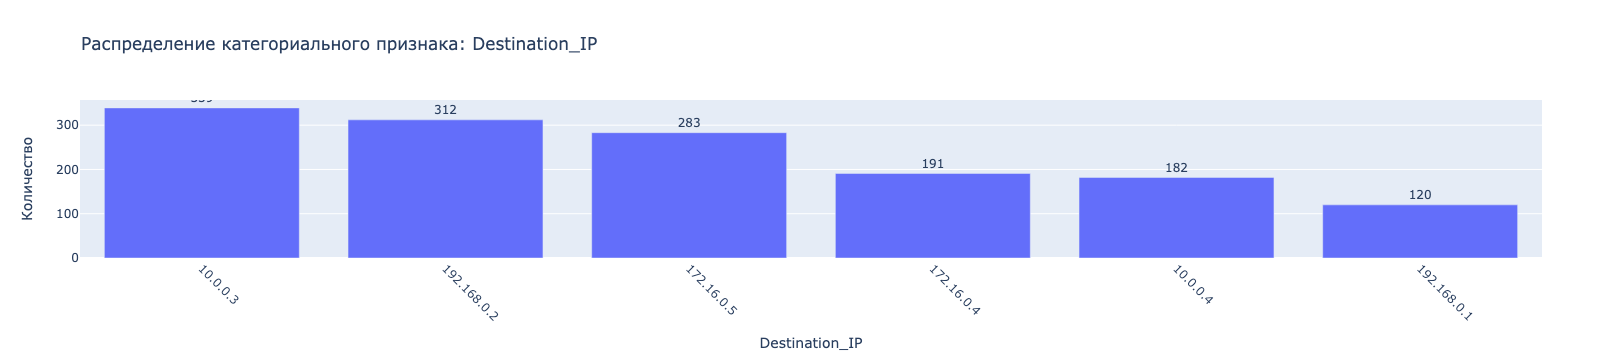

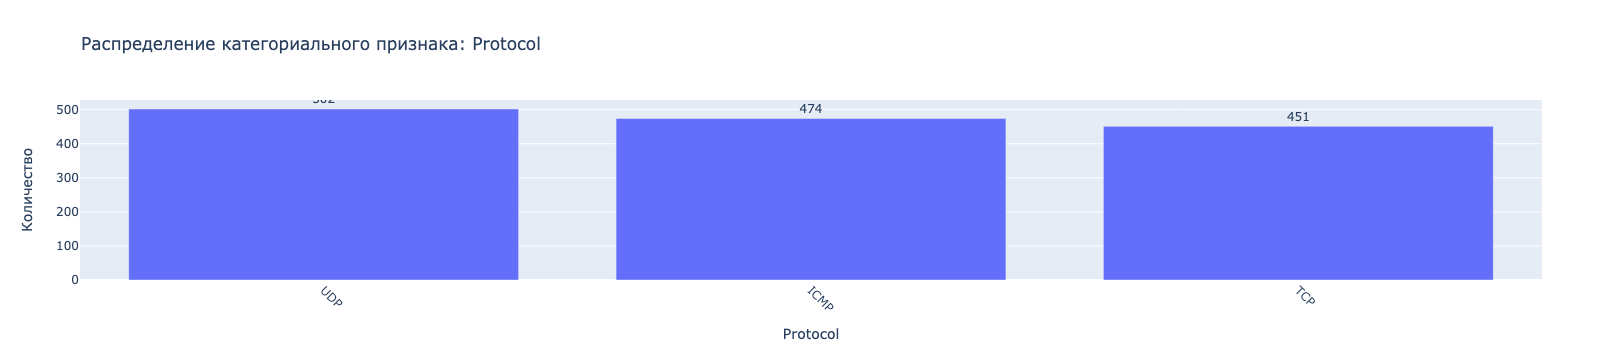

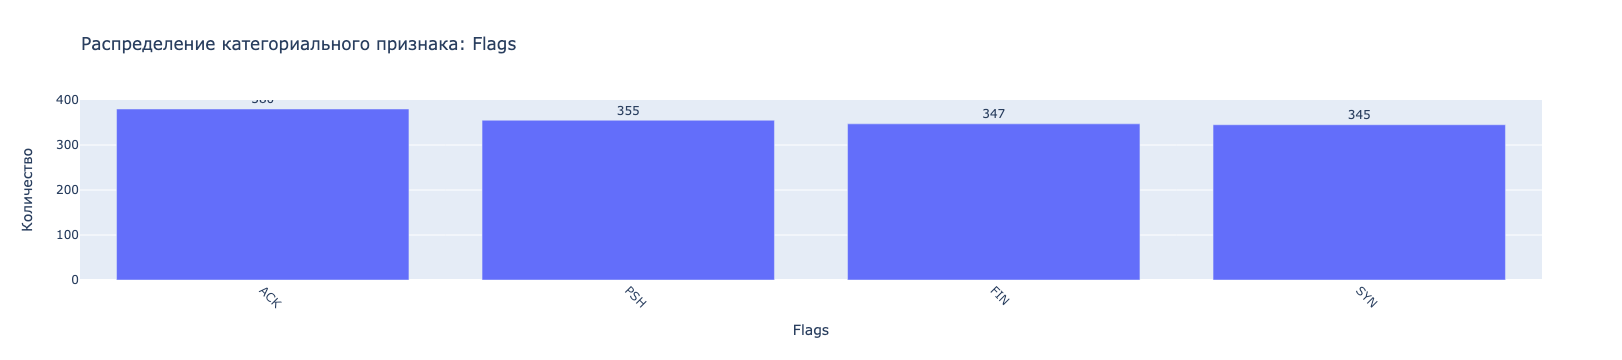

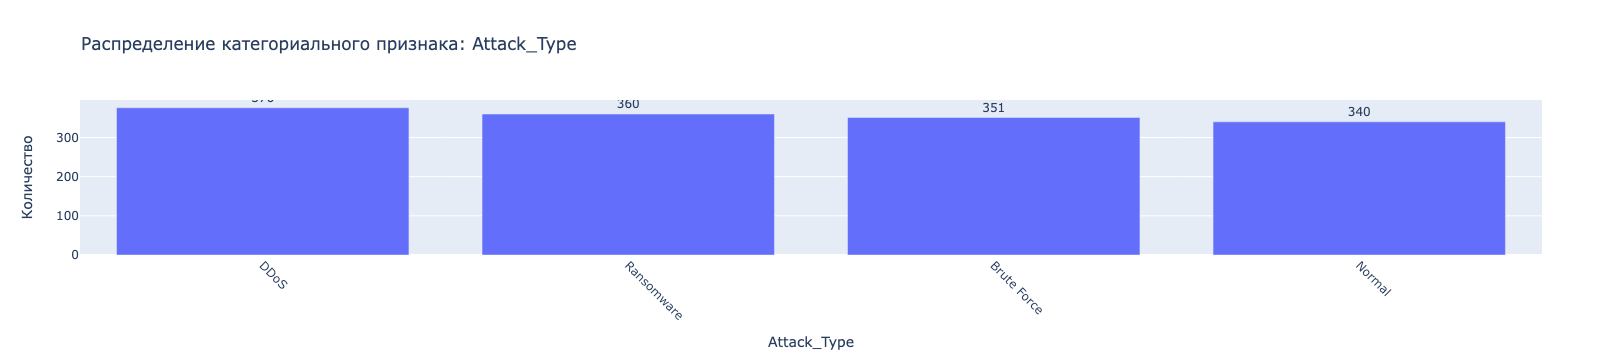

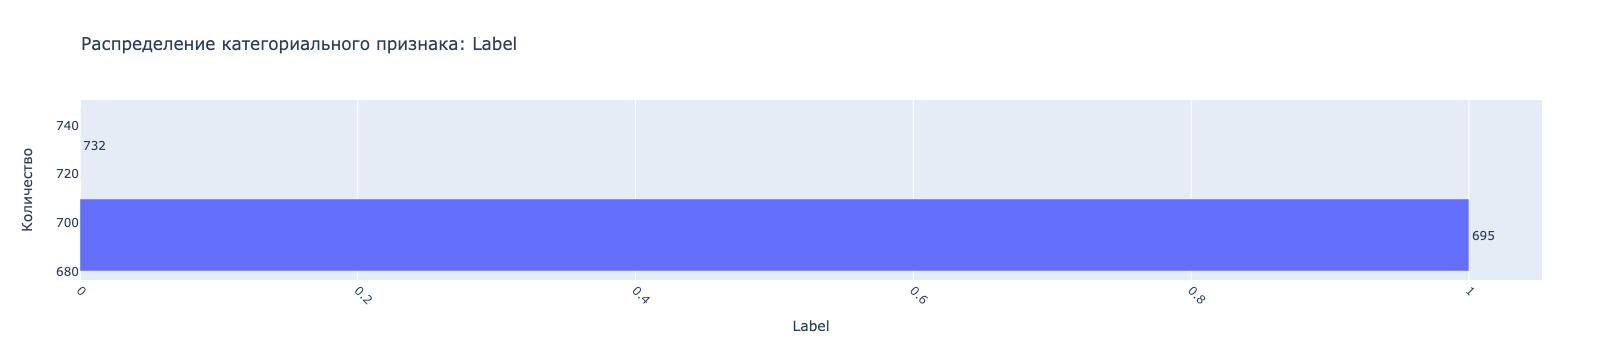

In [11]:
for col in cat_cols:
    vc = (
        df.group_by(col)
          .agg(pl.count().alias("counts"))
          .sort("counts", descending=True)
    )
    fig = px.bar(
        vc,
        x=col,
        y="counts",
        text="counts",
        title=f"Распределение категориального признака: {col}",
        labels={col: col, "counts": "Количество"},
    )
    fig.update_traces(textposition="outside")
    fig.update_layout(xaxis_tickangle=45)
    fig.show()

In [12]:
df = df.drop('Timestamp')

df

Source_IP,Destination_IP,Protocol,Packet_Length,Duration,Source_Port,Destination_Port,Bytes_Sent,Bytes_Received,Flags,Flow_Packets/s,Flow_Bytes/s,Avg_Packet_Size,Total_Fwd_Packets,Total_Bwd_Packets,Fwd_Header_Length,Bwd_Header_Length,Sub_Flow_Fwd_Bytes,Sub_Flow_Bwd_Bytes,Inbound,Attack_Type,Label
str,str,str,i64,f64,i64,i64,i64,i64,str,f64,f64,i64,i64,i64,i64,i64,i64,i64,i64,str,i64
"""192.168.0.1""","""192.168.0.1""","""ICMP""",1155,4.01,53,53,675,877,"""SYN""",37.9,583.2,512,21,34,256,256,697,1028,1,"""DDoS""",1
"""192.168.0.7""","""172.16.0.5""","""ICMP""",1776,3.75,22,22,297,1062,"""ACK""",37.8,1100.6,1024,14,19,512,256,513,1300,1,"""DDoS""",1
"""192.168.0.7""","""10.0.0.3""","""UDP""",627,4.24,80,8080,122,723,"""ACK""",12.3,339.1,512,10,41,512,256,250,497,0,"""DDoS""",1
"""192.168.0.7""","""10.0.0.3""","""UDP""",1754,3.09,443,443,1626,1703,"""FIN""",19.2,1913.5,256,37,44,128,256,985,1471,0,"""Ransomware""",0
"""192.168.0.1""","""10.0.0.4""","""UDP""",1326,2.52,80,443,1851,771,"""PSH""",16.2,105.9,1024,40,16,512,256,1877,595,1,"""Normal""",1
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""10.0.0.9""","""10.0.0.3""","""UDP""",1260,0.46,22,8080,722,626,"""PSH""",38.9,509.6,256,37,17,512,512,1021,1996,1,"""Ransomware""",1
"""10.0.0.9""","""172.16.0.5""","""TCP""",362,2.02,8080,22,571,1006,"""ACK""",16.6,596.8,1024,27,24,128,128,381,260,1,"""Normal""",1
"""172.16.0.4""","""10.0.0.3""","""TCP""",1236,2.11,8080,80,1194,185,"""ACK""",37.2,750.1,512,15,46,256,256,1064,170,1,"""Normal""",1


In [13]:
target_col = "Label"

numeric_cols = [c for c in df.select(pl.col(pl.NUMERIC_DTYPES)).columns if c != target_col]
df_num = df.select([target_col] + numeric_cols)

corrs = {}
for col in numeric_cols:
    corr, pval = pointbiserialr(df_num[target_col], df_num[col])
    corrs[col] = corr

corr_series = pl.DataFrame({
    "feature": list(corrs.keys()),
    "point_biserial_corr": list(corrs.values())
}).sort("point_biserial_corr", descending=True)

corr_series

feature,point_biserial_corr
str,f64
"""Sub_Flow_Bwd_Bytes""",0.020941
"""Flow_Packets/s""",0.020332
"""Flow_Bytes/s""",0.016045
"""Bwd_Header_Length""",0.011486
"""Duration""",0.011345
…,…
"""Bytes_Sent""",-0.023047
"""Total_Bwd_Packets""",-0.033787
"""Source_Port""",-0.041592


In [14]:
targets = ['Attack_Type', 'Label']
X = df.drop(targets)
y = df[targets]

In [15]:
X

Source_IP,Destination_IP,Protocol,Packet_Length,Duration,Source_Port,Destination_Port,Bytes_Sent,Bytes_Received,Flags,Flow_Packets/s,Flow_Bytes/s,Avg_Packet_Size,Total_Fwd_Packets,Total_Bwd_Packets,Fwd_Header_Length,Bwd_Header_Length,Sub_Flow_Fwd_Bytes,Sub_Flow_Bwd_Bytes,Inbound
str,str,str,i64,f64,i64,i64,i64,i64,str,f64,f64,i64,i64,i64,i64,i64,i64,i64,i64
"""192.168.0.1""","""192.168.0.1""","""ICMP""",1155,4.01,53,53,675,877,"""SYN""",37.9,583.2,512,21,34,256,256,697,1028,1
"""192.168.0.7""","""172.16.0.5""","""ICMP""",1776,3.75,22,22,297,1062,"""ACK""",37.8,1100.6,1024,14,19,512,256,513,1300,1
"""192.168.0.7""","""10.0.0.3""","""UDP""",627,4.24,80,8080,122,723,"""ACK""",12.3,339.1,512,10,41,512,256,250,497,0
"""192.168.0.7""","""10.0.0.3""","""UDP""",1754,3.09,443,443,1626,1703,"""FIN""",19.2,1913.5,256,37,44,128,256,985,1471,0
"""192.168.0.1""","""10.0.0.4""","""UDP""",1326,2.52,80,443,1851,771,"""PSH""",16.2,105.9,1024,40,16,512,256,1877,595,1
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""10.0.0.9""","""10.0.0.3""","""UDP""",1260,0.46,22,8080,722,626,"""PSH""",38.9,509.6,256,37,17,512,512,1021,1996,1
"""10.0.0.9""","""172.16.0.5""","""TCP""",362,2.02,8080,22,571,1006,"""ACK""",16.6,596.8,1024,27,24,128,128,381,260,1
"""172.16.0.4""","""10.0.0.3""","""TCP""",1236,2.11,8080,80,1194,185,"""ACK""",37.2,750.1,512,15,46,256,256,1064,170,1


In [16]:
y

Attack_Type,Label
str,i64
"""DDoS""",1
"""DDoS""",1
"""DDoS""",1
"""Ransomware""",0
"""Normal""",1
…,…
"""Ransomware""",1
"""Normal""",1
"""Normal""",1


In [17]:
numeric_cols = X.select(pl.col(pl.NUMERIC_DTYPES)).columns
cat_cols = [c for c in X.columns if c not in numeric_cols]

X = X.to_pandas()
y = y.to_pandas()

In [18]:
target = 'Attack_Type'

X_train, X_test, y_train, y_test = train_test_split(
    X, y[target], test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(1141, 20) (1141,)
(286, 20) (286,)


In [19]:
cat_transformer = make_pipeline(TargetEncoder())

preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), numeric_cols),
    ("cat", cat_transformer, cat_cols)
])

In [42]:
model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    # ("classifier", LogisticRegression(
    #     multi_class="multinomial",
    #     solver="lbfgs",
    #     max_iter=1000
    # ))
    ("classifier", SVC(kernel='rbf', probability=True))
])

model

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [43]:
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)  

In [44]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

 Brute Force       0.25      0.26      0.25        70
        DDoS       0.22      0.26      0.24        76
      Normal       0.25      0.22      0.23        68
  Ransomware       0.17      0.14      0.15        72

    accuracy                           0.22       286
   macro avg       0.22      0.22      0.22       286
weighted avg       0.22      0.22      0.22       286



In [45]:
!pip install catboost -q


[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: python3.11 -m pip install --upgrade pip


In [46]:
from catboost import Pool, CatBoostClassifier 

train_pool = Pool(X_train, y_train, cat_features=cat_cols)
test_pool = Pool(X_test, y_test, cat_features=cat_cols)

In [47]:
model = CatBoostClassifier(task_type="GPU")

model.fit(train_pool, verbose=100)

Learning rate set to 0.066676
0:	learn: 1.3811476	total: 7.21ms	remaining: 7.2s
100:	learn: 0.9892588	total: 598ms	remaining: 5.32s
200:	learn: 0.7748490	total: 1.17s	remaining: 4.64s
300:	learn: 0.6141969	total: 1.74s	remaining: 4.04s
400:	learn: 0.4896792	total: 2.32s	remaining: 3.46s
500:	learn: 0.4007011	total: 2.89s	remaining: 2.88s
600:	learn: 0.3279369	total: 3.48s	remaining: 2.31s
700:	learn: 0.2743038	total: 4.07s	remaining: 1.74s
800:	learn: 0.2313535	total: 4.64s	remaining: 1.15s
900:	learn: 0.1978822	total: 5.21s	remaining: 573ms
999:	learn: 0.1712207	total: 5.78s	remaining: 0us


In [48]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)

In [49]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

 Brute Force       0.28      0.30      0.29        70
        DDoS       0.24      0.24      0.24        76
      Normal       0.31      0.25      0.28        68
  Ransomware       0.18      0.21      0.19        72

    accuracy                           0.25       286
   macro avg       0.25      0.25      0.25       286
weighted avg       0.25      0.25      0.25       286



In [37]:
# На бустинге качество сильно не выросло, а значит дело не в коррелированных фичах / проклятии размерности